In [35]:
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter
import ast

In [36]:
ats_df = pd.read_csv(
    r"D:\AI_ATS_Resume_Screening_System\resume\test\csv\final_ats_results.csv"
)

ats_df.head()

,resume_name,resume_text,text_length,length_category,completeness_score,clean_text,skills_found,skill_count,similarity_score,match_percentage,skill_score,final_score,ATS_Rank,matched_skills,missing_skills,missing_skill_count,recommendation
0,Niteesh Java Developer.pdf,Niteesh Kusumba\nniteeshkusumba.java@gmail.com...,21020,Long,3,niteesh kusumba sr java full stack developer c...,"['python', 'sql', 'excel', 'r', 'mysql', 'gith...",6,0.146991,100.000000,40,22.289359,1,"['python', 'sql']","['statistics', 'power bi', 'data analysis', 'm...",6,"Recommended to learn: statistics, power bi, da..."
1,Bapuji Hadoop developer.pdf,Bapuji\nSr. Hadoop Developer\nPhone: +1(224)-7...,14384,Long,4,bapuji sr hadoop developer phone email profess...,"['python', 'sql', 'excel', 'tableau', 'r', 'my...",9,0.088774,95.176116,50,21.214146,2,"['python', 'sql']","['statistics', 'power bi', 'data analysis', 'm...",6,"Recommended to learn: statistics, power bi, da..."
2,Sai Srinivas_Sr_Java_Developer.pdf,Sai Srinivas\nSr. Java/J2EE Developer\nCell: (...,21215,Long,3,sai srinivas sr javajee developer cell email s...,"['python', 'sql', 'excel', 'r', 'mysql', 'gith...",8,0.108027,87.763342,40,19.561886,3,"['python', 'sql']","['statistics', 'power bi', 'data analysis', 'm...",6,"Recommended to learn: statistics, power bi, da..."
3,Venkata_SrPHP_Developer.pdf,Venkata\nSr. PHP / Drupal Developer\nEmail: ve...,9953,Long,3,venkata sr php drupal developer email cell sum...,"['python', 'sql', 'excel', 'r', 'sas', 'mysql']",6,0.145222,85.985031,30,19.165512,4,"['python', 'sql']","['statistics', 'power bi', 'data analysis', 'm...",6,"Recommended to learn: statistics, power bi, da..."
4,Mani_Hadoop.pdf,Mani\nSr. Hadoop Developer\nEmail: vmaniv08@gm...,13562,Long,3,mani sr hadoop developer email contact profess...,"['python', 'sql', 'excel', 'tableau', 'r', 'my...",8,0.093595,83.230969,40,18.551650,5,"['python', 'sql']","['statistics', 'power bi', 'data analysis', 'm...",6,"Recommended to learn: statistics, power bi, da..."


In [37]:
total_candidates = len(ats_df)

average_score = round(
    ats_df["match_percentage"].mean(),
    2
)

highest_score = ats_df["match_percentage"].max()

lowest_score = ats_df["match_percentage"].min()

top_candidate = ats_df.iloc[0]["resume_name"]

print("Total Candidates:", total_candidates)

print("Average ATS Score:", average_score)

print("Highest Score:", highest_score)

print("Lowest Score:", lowest_score)

print("Top Candidate:", top_candidate)

Total Candidates: 28
Average ATS Score: 50.71
Highest Score: 100.0
Lowest Score: 24.108170244478146
Top Candidate: Niteesh Java Developer.pdf


In [38]:
def score_category(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Average"

    else:
        return "Low"

In [39]:
ats_df["score_category"] = (
    ats_df["match_percentage"]
    .apply(score_category)
)

In [40]:
category_counts = (
    ats_df["score_category"]
    .value_counts()
)

print(category_counts)

score_category
Low          11
Average      10
Excellent     5
Good          2
Name: count, dtype: int64


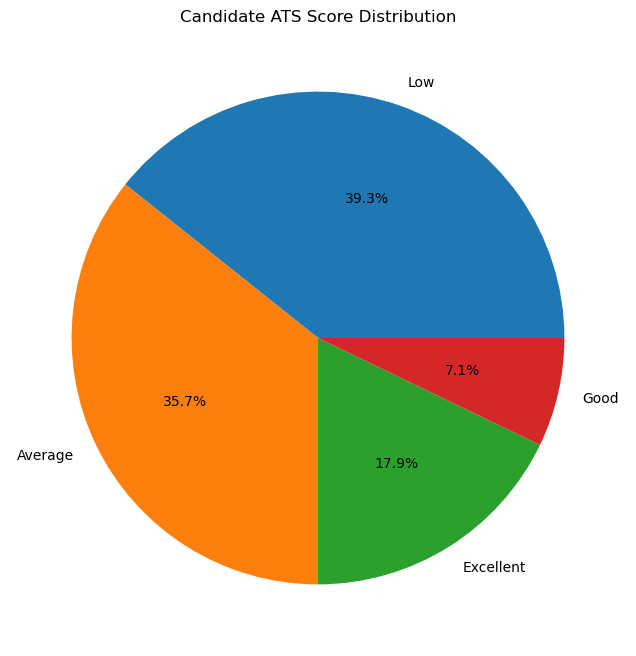

In [41]:
plt.figure(figsize=(8,8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Candidate ATS Score Distribution"
)

plt.show()

In [42]:
top_10 = ats_df.head(10)

top_10[
    [
        "resume_name",
        "match_percentage"
    ]
]

,resume_name,match_percentage
0,Niteesh Java Developer.pdf,100.000000
1,Bapuji Hadoop developer.pdf,95.176116
2,Sai Srinivas_Sr_Java_Developer.pdf,87.763342
3,Venkata_SrPHP_Developer.pdf,85.985031
4,Mani_Hadoop.pdf,83.230969
5,RaviBurra_Certified PM_DevOps.pdf,79.255553
6,Tarun_Developer.pdf,79.176417
7,vikas java.pdf,48.670268
8,Sundar_Java_8 Years.pdf,48.670268
9,Sumanth Manne Java Developer.pdf,48.670268


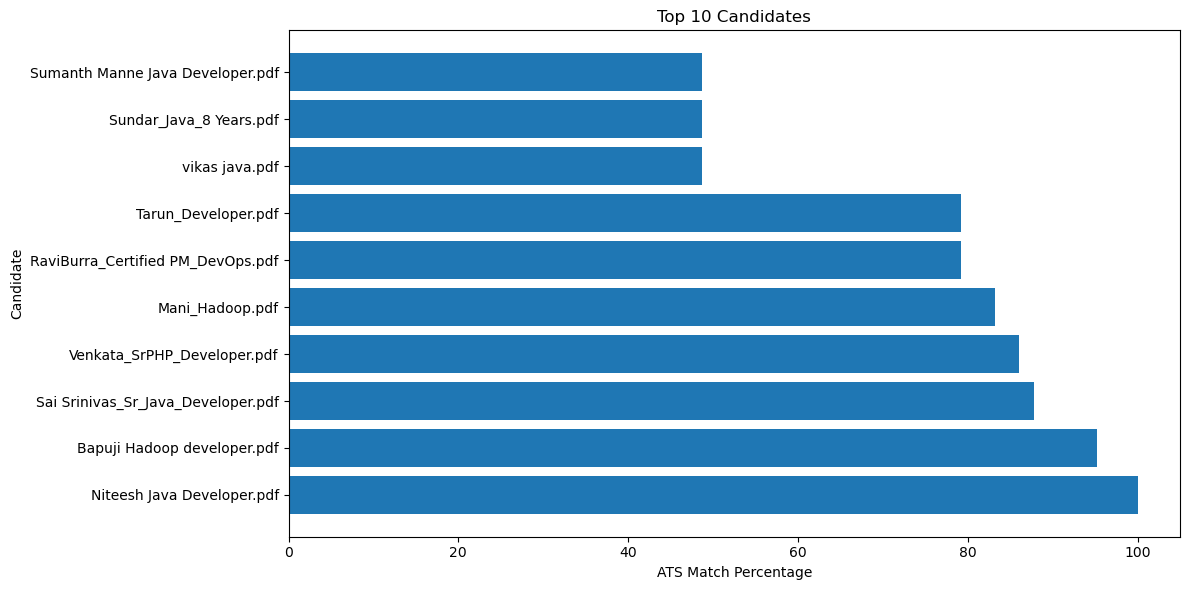

In [43]:
plt.figure(figsize=(12,6))

plt.barh(
    top_10["resume_name"],
    top_10["match_percentage"]
)

plt.xlabel("ATS Match Percentage")

plt.ylabel("Candidate")

plt.title("Top 10 Candidates")

plt.tight_layout()

plt.show()

In [44]:
import ast

def convert_to_list(skill_string):

    try:
        return ast.literal_eval(skill_string)

    except:
        return []

ats_df["skills_found"] = (
    ats_df["skills_found"]
    .apply(convert_to_list)
)

In [45]:
all_skills = []

for skill_list in ats_df["skills_found"]:

    all_skills.extend(skill_list)

skill_counter = Counter(all_skills)

print(skill_counter)

Counter({'sql': 28, 'r': 28, 'mysql': 25, 'excel': 21, 'github': 12, 'sas': 11, 'spark': 9, 'python': 7, 'hadoop': 6, 'postgresql': 5, 'tableau': 2})


In [46]:
top_skills = skill_counter.most_common(10)

top_skills

[('sql', 28),
 ('r', 28),
 ('mysql', 25),
 ('excel', 21),
 ('github', 12),
 ('sas', 11),
 ('spark', 9),
 ('python', 7),
 ('hadoop', 6),
 ('postgresql', 5)]

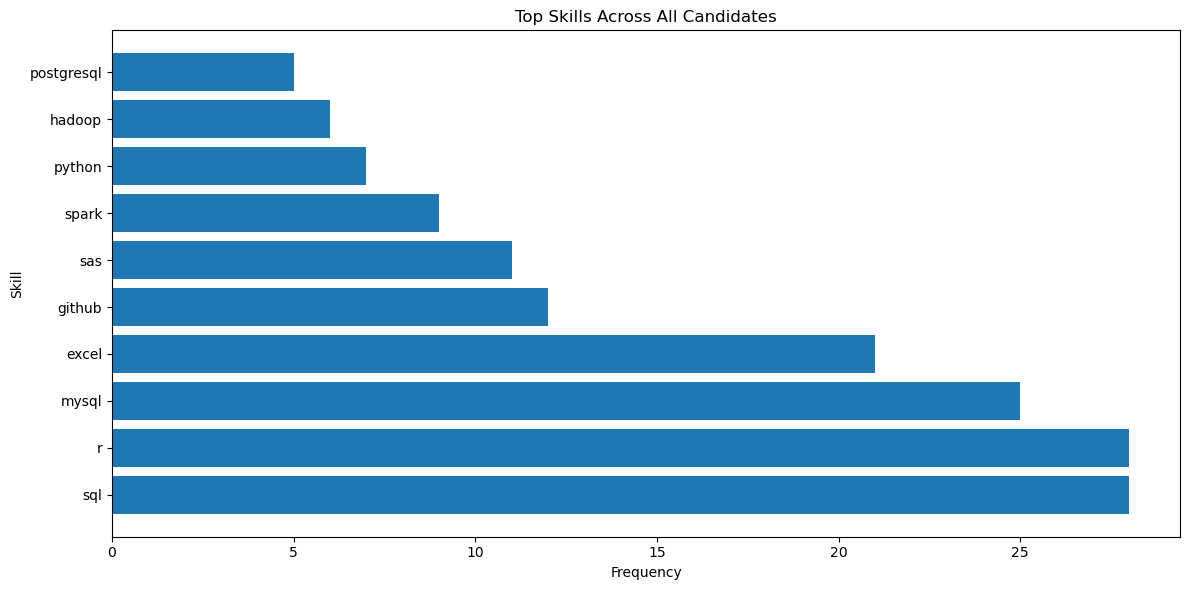

In [47]:
skill_names = [x[0] for x in top_skills]

skill_counts = [x[1] for x in top_skills]

plt.figure(figsize=(12,6))

plt.barh(
    skill_names,
    skill_counts
)

plt.title(
    "Top Skills Across All Candidates"
)

plt.xlabel("Frequency")

plt.ylabel("Skill")

plt.tight_layout()

plt.show()

In [48]:
ats_df.to_csv(
    r"D:\AI_ATS_Resume_Screening_System\resume\test\csv\dashboard_data.csv",
    index=False
)

print("Dashboard dataset saved successfully!")

Dashboard dataset saved successfully!
